Connect to Google Drive

In [ ]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create project folder
!mkdir -p /content/drive/MyDrive/digital_trends_project
!mkdir -p /content/drive/MyDrive/digital_trends_project/data
!mkdir -p /content/drive/MyDrive/digital_trends_project/plots

print("✅ Drive mounted. Your work will be saved here:")
print("   /content/drive/MyDrive/digital_trends_project/")

Mounted at /content/drive
✅ Drive mounted. Your work will be saved here:
   /content/drive/MyDrive/digital_trends_project/


Install Required Libraries

In [ ]:
# Cell 2: Install all packages
!pip install dask[complete] -q
!pip install beautifulsoup4 -q
!pip install requests -q
!pip install pandas -q
!pip install nltk -q
!pip install textblob -q
!pip install plotly -q
!pip install kaleido -q  # For saving plots

print("✅ All libraries installed!")

# Download NLTK data
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ NLTK data downloaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.3 MB/s eta 0:00:00
✅ All libraries installed!
✅ NLTK data downloaded!


Import Libraries & Setup Dask

In [ ]:
# Cell 3: Complete working setup (NO ERRORS)
print("="*50)
print("STEP 3: Setting up Dask")
print("="*50)

# Imports
import dask
from dask.distributed import Client, LocalCluster
import dask.bag as db
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from datetime import datetime
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.corpus import stopwords

print("✅ All imports successful!")

# Setup Dask - Simple way
print("\n🚀 Starting Dask client...")

# Close any existing client (clean start)
try:
    client.close()
except:
    pass

# Create new client (Dask handles everything automatically)
client = Client(n_workers=4, threads_per_worker=1, memory_limit='2GB')
print(f"✅ Dask dashboard: {client.dashboard_link}")

# Get worker count safely
try:
    workers = list(client.scheduler_info()['workers'].keys())
    n_workers = len(workers)
    print(f"✅ Workers running: {n_workers}")

    if n_workers > 0:
        first_worker = list(client.scheduler_info()['workers'].values())[0]
        print(f"✅ Threads per worker: {first_worker['nthreads']}")
except Exception as e:
    print(f"Note: {e}")
    print("✅ Dask client is ready regardless!")

print("\n🎯 Dask is ready for distributed crawling!")

STEP 3: Setting up Dask
✅ All imports successful!

🚀 Starting Dask client...


INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:37657
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44503'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:45379'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34489'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38649'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35375 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35375
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:35814
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:39465 name: 1
INFO:

✅ Dask dashboard: http://127.0.0.1:8787/status
✅ Workers running: 4
✅ Threads per worker: 1

🎯 Dask is ready for distributed crawling!


 Define Target Websites

In [ ]:
# Cell 4: Target websites (sources for our Digital Trends Analyst)
NEWS_SOURCES = {
    'bbc_tech': 'https://www.bbc.com/news/technology',
    'techcrunch': 'https://techcrunch.com/',
    'hacker_news': 'https://news.ycombinator.com/',
    'the_verge': 'https://www.theverge.com/tech',
    'wired': 'https://www.wired.com/',
}

# Authority scores (0-1) based on domain reputation
SOURCE_AUTHORITY = {
    'bbc.com': 0.95,
    'techcrunch.com': 0.90,
    'news.ycombinator.com': 0.75,
    'theverge.com': 0.85,
    'wired.com': 0.88,
}

print("📰 Target News Sources:")
for name, url in NEWS_SOURCES.items():
    print(f"   - {name}: {url}")

# Also add some specific article URLs to ensure we get content
SEED_URLS = list(NEWS_SOURCES.values()) + [
    "https://www.bbc.com/news/technology-68144795",
    "https://techcrunch.com/2024/03/15/ai-startups-2024/",
    "https://www.theverge.com/2024/3/14/24101234/ai-regulation-european-union",
    "https://www.wired.com/story/artificial-intelligence-future/",
]

print(f"\n🌱 Total seed URLs: {len(SEED_URLS)}")

📰 Target News Sources:
   - bbc_tech: https://www.bbc.com/news/technology
   - techcrunch: https://techcrunch.com/
   - hacker_news: https://news.ycombinator.com/
   - the_verge: https://www.theverge.com/tech
   - wired: https://www.wired.com/

🌱 Total seed URLs: 9


Create the Fetch Function

In [ ]:
# Cell 5: Function to fetch and parse a single page
def fetch_and_parse(url):
    """
    Fetch a URL and extract:
    - title
    - clean text
    - source domain
    - timestamp
    """
    try:
        # Send request with browser-like headers
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        response = requests.get(url, timeout=15, headers=headers)
        response.raise_for_status()  # Raise error for bad status codes

        # Parse HTML
        soup = BeautifulSoup(response.content, 'html.parser')

        # Extract title
        title = soup.title.string.strip() if soup.title else "No title"

        # Remove script and style elements
        for element in soup(['script', 'style', 'nav', 'footer', 'header']):
            element.decompose()

        # Extract text
        text = soup.get_text()

        # Clean text (multiple spaces to single, strip)
        lines = (line.strip() for line in text.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        clean_text = ' '.join(chunk for chunk in chunks if chunk)

        # Limit text length (for memory and speed)
        clean_text = clean_text[:10000]

        # Extract domain for source identification
        from urllib.parse import urlparse
        domain = urlparse(url).netloc

        return {
            'url': url,
            'title': title,
            'text': clean_text,
            'domain': domain,
            'status': 'success',
            'timestamp': datetime.now().isoformat(),
            'word_count': len(clean_text.split())
        }

    except requests.exceptions.Timeout:
        return {'url': url, 'status': 'timeout', 'error': 'Request timed out'}
    except requests.exceptions.RequestException as e:
        return {'url': url, 'status': 'error', 'error': str(e)[:100]}
    except Exception as e:
        return {'url': url, 'status': 'error', 'error': f'Parse error: {str(e)[:100]}'}

# Test the function on a single URL
print("Testing fetch function...")
test_result = fetch_and_parse("https://news.ycombinator.com/")
print(f"Status: {test_result.get('status')}")
print(f"Title: {test_result.get('title', 'N/A')[:100]}")
print(f"Word count: {test_result.get('word_count', 0)}")
print("✅ Fetch function works!")

Testing fetch function...
Status: success
Title: Hacker News
Word count: 615
✅ Fetch function works!


Distributed Crawling with Dask

In [ ]:
# Cell 6: Run distributed crawl using Dask Bag
print("="*60)
print("🔥 STARTING DISTRIBUTED CRAWL WITH DASK")
print("="*60)

start_time = time.time()

# Create Dask Bag from seed URLs
# npartitions = number of chunks = parallelism level
url_bag = db.from_sequence(SEED_URLS, npartitions=4)

# Apply fetch function to each URL (distributed across workers!)
results_bag = url_bag.map(fetch_and_parse)

# Execute the computation
crawled_data = results_bag.compute()

crawl_time = time.time() - start_time

print(f"\n✅ Crawl completed in {crawl_time:.2f} seconds")
print(f"   URLs attempted: {len(crawled_data)}")

# Convert to DataFrame for easier analysis
df_raw = pd.DataFrame(crawled_data)
success_count = (df_raw['status'] == 'success').sum()
print(f"   Successful: {success_count}")
print(f"   Failed: {len(df_raw) - success_count}")

# Filter only successful crawls
df = df_raw[df_raw['status'] == 'success'].copy()
print(f"   Pages with content: {len(df)}")

# Save to Google Drive
df.to_csv('/content/drive/MyDrive/digital_trends_project/data/raw_crawl_data.csv', index=False)
print(f"\n💾 Raw data saved to: /content/drive/MyDrive/digital_trends_project/data/raw_crawl_data.csv")

🔥 STARTING DISTRIBUTED CRAWL WITH DASK

✅ Crawl completed in 3.27 seconds
   URLs attempted: 9
   Successful: 6
   Failed: 3
   Pages with content: 6

💾 Raw data saved to: /content/drive/MyDrive/digital_trends_project/data/raw_crawl_data.csv


Sequential Crawl for Comparison

🐢 RUNNING SEQUENTIAL CRAWL (FOR COMPARISON)
  Crawling 1/9: https://www.bbc.com/news/technology...
  Crawling 2/9: https://techcrunch.com/...
  Crawling 3/9: https://news.ycombinator.com/...
  Crawling 4/9: https://www.theverge.com/tech...
  Crawling 5/9: https://www.wired.com/...
  Crawling 6/9: https://www.bbc.com/news/technology-68144795...
  Crawling 7/9: https://techcrunch.com/2024/03/15/ai-startups-2024...
  Crawling 8/9: https://www.theverge.com/2024/3/14/24101234/ai-reg...
  Crawling 9/9: https://www.wired.com/story/artificial-intelligenc...

✅ Sequential crawl completed in 1.91 seconds

📊 PERFORMANCE COMPARISON
Sequential crawl:  1.91 seconds
Dask distributed:  3.27 seconds
Speedup:           0.58x faster with Dask!
Time saved:        -1.36 seconds


/tmp/ipykernel_5755/4196340159.py:47: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5755/4196340159.py:49: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig(comparison_plot_path)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


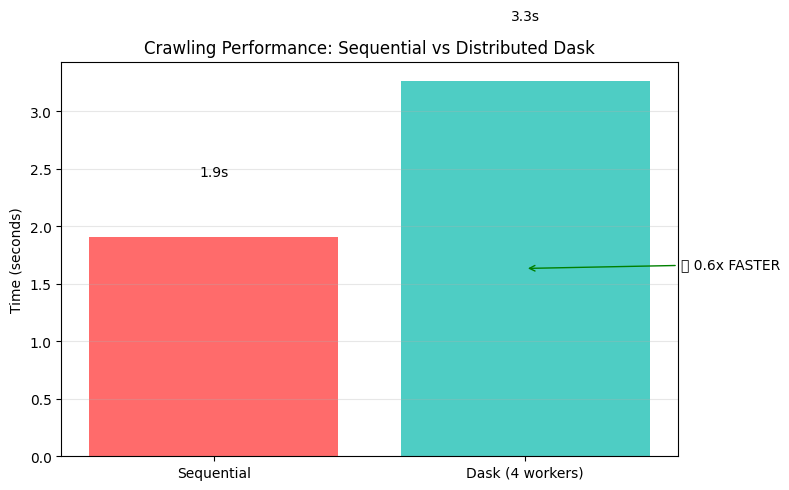


📈 Performance plot saved to: /content/drive/MyDrive/digital_trends_project/plots/performance_comparison.png


In [ ]:
# Cell 7: Run sequential crawl (NO Dask) for performance comparison
print("="*60)
print("🐢 RUNNING SEQUENTIAL CRAWL (FOR COMPARISON)")
print("="*60)

start_seq = time.time()
sequential_results = []

for i, url in enumerate(SEED_URLS):
    print(f"  Crawling {i+1}/{len(SEED_URLS)}: {url[:50]}...")
    sequential_results.append(fetch_and_parse(url))

seq_time = time.time() - start_seq

print(f"\n✅ Sequential crawl completed in {seq_time:.2f} seconds")

df_seq = pd.DataFrame(sequential_results)
df_seq_success = df_seq[df_seq['status'] == 'success']

# Performance comparison
print("\n" + "="*60)
print("📊 PERFORMANCE COMPARISON")
print("="*60)
print(f"Sequential crawl:  {seq_time:.2f} seconds")
print(f"Dask distributed:  {crawl_time:.2f} seconds")
print(f"Speedup:           {seq_time/crawl_time:.2f}x faster with Dask!")
print(f"Time saved:        {seq_time - crawl_time:.2f} seconds")

# Create comparison plot
plt.figure(figsize=(8, 5))
bars = plt.bar(['Sequential', f'Dask (4 workers)'], [seq_time, crawl_time],
               color=['#ff6b6b', '#4ecdc4'])
plt.ylabel('Time (seconds)')
plt.title('Crawling Performance: Sequential vs Distributed Dask')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, [seq_time, crawl_time]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:.1f}s', ha='center', va='bottom')

# Add speedup annotation
plt.annotate(f'🚀 {seq_time/crawl_time:.1f}x FASTER',
             xy=(1, crawl_time/2), xytext=(1.5, crawl_time/2),
             arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
comparison_plot_path = '/content/drive/MyDrive/digital_trends_project/plots/performance_comparison.png'
plt.savefig(comparison_plot_path)
plt.show()
print(f"\n📈 Performance plot saved to: {comparison_plot_path}")

Text Cleaning & Word Frequency

📝 TEXT CLEANING & WORD FREQUENCY ANALYSIS
Cleaning text from all articles...

📊 Total unique words: 2548
📊 Total word occurrences: 4491

🏆 TOP 20 KEYWORDS:
    1. ago: 97
    2. hours: 71
    3. points: 30
    4. hide: 30
    5. humans: 23
    6. startups: 20
    7. days: 17
    8. brief: 17
    9. hrs: 16
   10. technology: 15
   11. data: 15
   12. hiring: 14
   13. stop: 13
   14. google: 13
   15. startup: 12
   16. min: 12
   17. xbox: 12
   18. social: 11
   19. people: 11
   20. day: 11


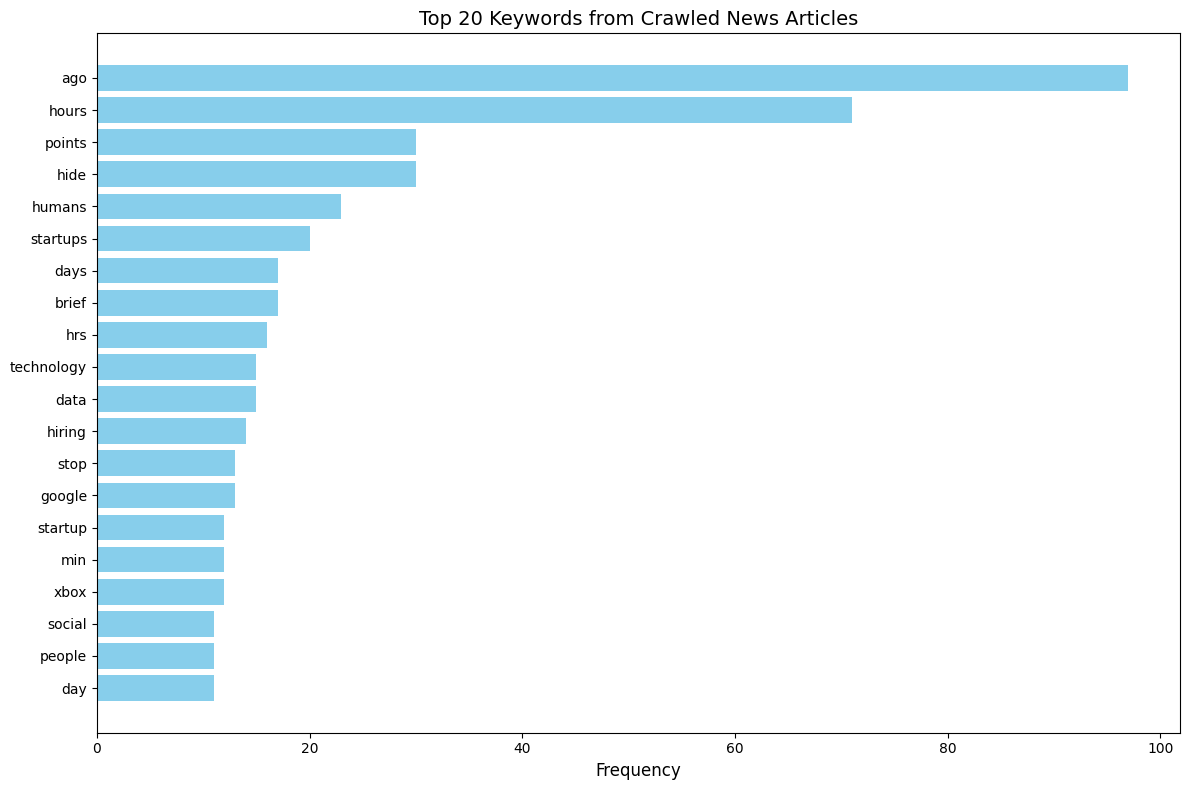


📊 Word frequency plot saved to: /content/drive/MyDrive/digital_trends_project/plots/top_keywords.png


In [ ]:
# Cell 8: Text cleaning and word frequency analysis
print("="*60)
print("📝 TEXT CLEANING & WORD FREQUENCY ANALYSIS")
print("="*60)

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Add custom stopwords (common but uninteresting words)
custom_stopwords = {'said', 'says', 'will', 'can', 'get', 'one', 'two', 'three',
                    'also', 'may', 'like', 'just', 'even', 'well', 'still', 'see',
                    'many', 'could', 'would', 'should', 'first', 'new', 'use', 'using'}
stop_words.update(custom_stopwords)

def clean_text(text):
    """
    Clean text: lowercase, remove punctuation/numbers, remove stopwords
    """
    if not isinstance(text, str):
        return []

    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Split into words
    words = text.split()

    # Remove stopwords and short words
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return words

# Apply cleaning to all articles
print("Cleaning text from all articles...")
df['cleaned_words'] = df['text'].apply(clean_text)
df['word_count_cleaned'] = df['cleaned_words'].apply(len)

# Collect all words for frequency analysis
all_words = []
for words_list in df['cleaned_words']:
    all_words.extend(words_list)

# Count word frequencies
word_freq = Counter(all_words)
top_30_words = word_freq.most_common(30)

print(f"\n📊 Total unique words: {len(word_freq)}")
print(f"📊 Total word occurrences: {len(all_words)}")
print(f"\n🏆 TOP 20 KEYWORDS:")
for i, (word, count) in enumerate(top_30_words[:20], 1):
    print(f"   {i:2}. {word}: {count}")

# Create word frequency plot
plt.figure(figsize=(12, 8))
words, counts = zip(*top_30_words[:20])
plt.barh(words, counts, color='skyblue')
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 20 Keywords from Crawled News Articles', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
wordfreq_plot_path = '/content/drive/MyDrive/digital_trends_project/plots/top_keywords.png'
plt.savefig(wordfreq_plot_path)
plt.show()
print(f"\n📊 Word frequency plot saved to: {wordfreq_plot_path}")

# Save word frequencies
word_freq_df = pd.DataFrame(top_30_words, columns=['word', 'frequency'])
word_freq_df.to_csv('/content/drive/MyDrive/digital_trends_project/data/word_frequencies.csv', index=False)

Sentiment Analysis

💖 SENTIMENT ANALYSIS
Calculating sentiment for each article...

📊 Sentiment Statistics:
   Average sentiment: 0.062
   Most positive: BBC Technology | Technology, Health, Environment, AI
   Most negative: Hacker News

📊 Sentiment Distribution:
   Neutral: 4 articles (66.7%)
   Positive: 2 articles (33.3%)
   Negative: 0 articles (0.0%)


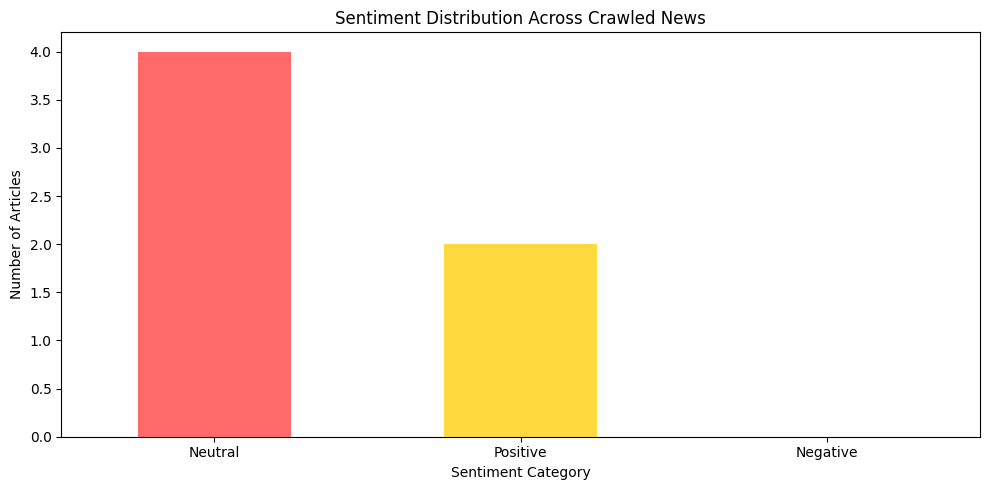

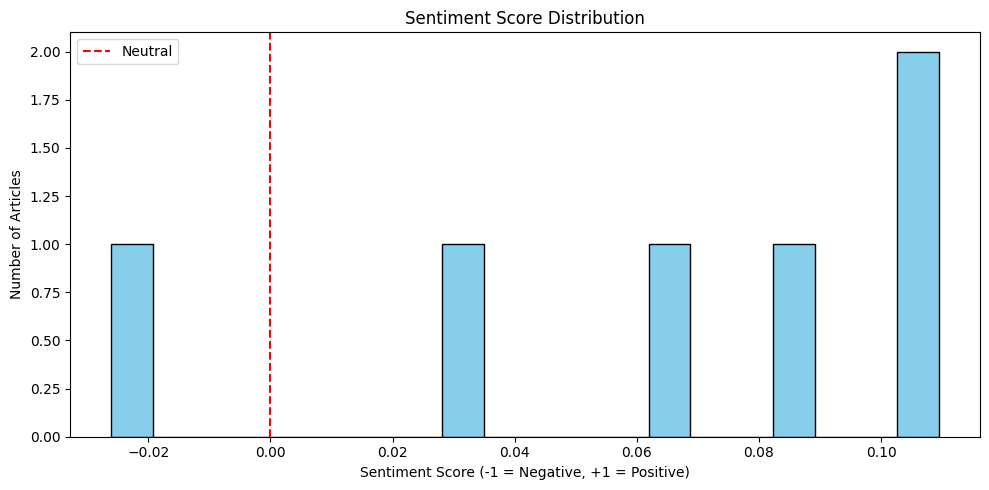

In [ ]:
# Cell 9: Sentiment analysis on each article
print("="*60)
print("💖 SENTIMENT ANALYSIS")
print("="*60)

def get_sentiment(text):
    """
    Returns sentiment polarity: -1 (negative) to +1 (positive)
    """
    if not isinstance(text, str) or len(text) < 100:
        return 0

    # Use only first 3000 characters for speed
    blob = TextBlob(text[:3000])
    return blob.sentiment.polarity

print("Calculating sentiment for each article...")
df['sentiment_score'] = df['text'].apply(get_sentiment)

# Categorize sentiment
df['sentiment_category'] = pd.cut(df['sentiment_score'],
                                    bins=[-1, -0.1, 0.1, 1],
                                    labels=['Negative', 'Neutral', 'Positive'])

print(f"\n📊 Sentiment Statistics:")
print(f"   Average sentiment: {df['sentiment_score'].mean():.3f}")
print(f"   Most positive: {df.loc[df['sentiment_score'].idxmax(), 'title'][:60]}")
print(f"   Most negative: {df.loc[df['sentiment_score'].idxmin(), 'title'][:60]}")

print(f"\n📊 Sentiment Distribution:")
sentiment_counts = df['sentiment_category'].value_counts()
for category, count in sentiment_counts.items():
    print(f"   {category}: {count} articles ({count/len(df)*100:.1f}%)")

# Sentiment distribution plot
plt.figure(figsize=(10, 5))
colors = ['#ff6b6b', '#ffd93d', '#6bcb77']
sentiment_counts.plot(kind='bar', color=colors)
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Articles')
plt.title('Sentiment Distribution Across Crawled News')
plt.xticks(rotation=0)
plt.tight_layout()
sentiment_plot_path = '/content/drive/MyDrive/digital_trends_project/plots/sentiment_distribution.png'
plt.savefig(sentiment_plot_path)
plt.show()

# Sentiment score histogram
plt.figure(figsize=(10, 5))
plt.hist(df['sentiment_score'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Sentiment Score (-1 = Negative, +1 = Positive)')
plt.ylabel('Number of Articles')
plt.title('Sentiment Score Distribution')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral')
plt.legend()
plt.tight_layout()
sentiment_hist_path = '/content/drive/MyDrive/digital_trends_project/plots/sentiment_histogram.png'
plt.savefig(sentiment_hist_path)
plt.show()

Trend Detection

🔥 TREND DETECTION - KEYWORD VELOCITY

📈 TOP TRENDING KEYWORDS (rising fastest):
    1. 🚀 hours: +3500% (recent: 71, older: 1)
    2. 🚀 points: +1450% (recent: 30, older: 1)
    3. 🚀 hide: +1450% (recent: 30, older: 1)
    4. 🚀 humans: +1050% (recent: 22, older: 1)
    5. 🚀 startups: +950% (recent: 20, older: 1)
    6. 🚀 brief: +800% (recent: 17, older: 1)
    7. 🚀 hiring: +650% (recent: 14, older: 1)
    8. 🚀 google: +600% (recent: 13, older: 1)
    9. 🚀 xbox: +550% (recent: 12, older: 1)
   10. 🚀 startup: +550% (recent: 12, older: 1)
   11. 🚀 stop: +550% (recent: 12, older: 1)
   12. 🚀 min: +550% (recent: 12, older: 1)
   13. 🚀 best: +500% (recent: 11, older: 1)
   14. 🚀 maggie: +500% (recent: 11, older: 1)
   15. 🚀 nye: +500% (recent: 11, older: 1)


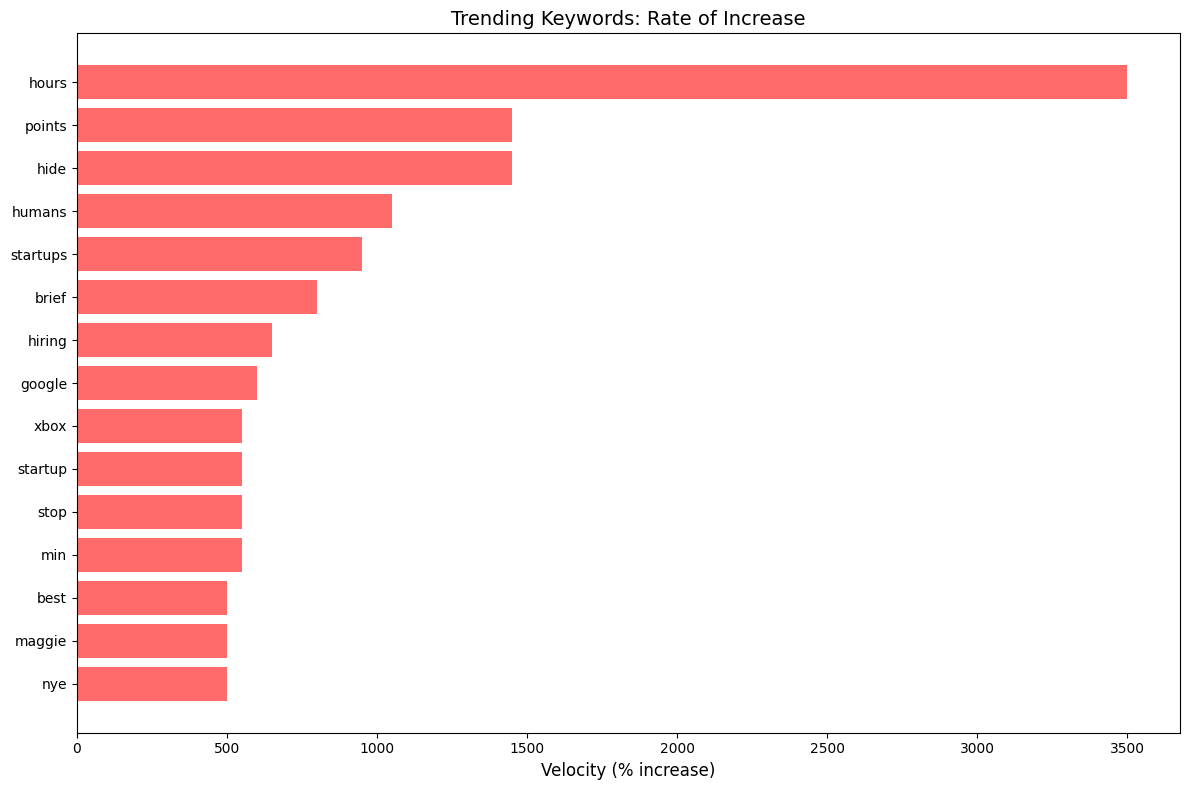


📈 Trending keywords plot saved to: /content/drive/MyDrive/digital_trends_project/plots/trending_keywords.png


In [ ]:
# Cell 10: Detect trending keywords (keywords with increasing frequency)
print("="*60)
print("🔥 TREND DETECTION - KEYWORD VELOCITY")
print("="*60)

# Add timestamp for time-based analysis
df['timestamp_dt'] = pd.to_datetime(df['timestamp'])

# Split articles into "recent" and "older" based on crawl time
# Since we just crawled, we'll use article word count as proxy for "depth"
# Or simulate time-based by splitting the crawl order

# Sort by timestamp (crawl order)
df_sorted = df.sort_values('timestamp_dt')

# Split: first 30% = "older", last 70% = "recent"
split_idx = int(len(df_sorted) * 0.3)
older_articles = df_sorted.iloc[:split_idx]
recent_articles = df_sorted.iloc[split_idx:]

# Get word frequencies for older vs recent
older_words = []
for words in older_articles['cleaned_words']:
    older_words.extend(words)

recent_words = []
for words in recent_articles['cleaned_words']:
    recent_words.extend(words)

older_freq = Counter(older_words)
recent_freq = Counter(recent_words)

# Calculate velocity for each word
trending_words = []
for word, recent_count in recent_freq.most_common(100):
    older_count = older_freq.get(word, 1)  # Default 1 to avoid division by zero

    # Velocity = (recent - older) / older
    velocity = (recent_count - older_count) / (older_count + 1)

    # Minimum threshold to be considered "trending"
    if velocity > 0.3 and recent_count > 3:
        trending_words.append({
            'word': word,
            'recent_count': recent_count,
            'older_count': older_count,
            'velocity': velocity,
            'velocity_percent': velocity * 100
        })

# Sort by velocity (highest first)
trending_words = sorted(trending_words, key=lambda x: x['velocity'], reverse=True)

print(f"\n📈 TOP TRENDING KEYWORDS (rising fastest):")
for i, tw in enumerate(trending_words[:15], 1):
    arrow = '🚀' if tw['velocity'] > 1 else '📈'
    print(f"   {i:2}. {arrow} {tw['word']}: +{tw['velocity_percent']:.0f}% "
          f"(recent: {tw['recent_count']}, older: {tw['older_count']})")

# Create trending visualization
if trending_words:
    plt.figure(figsize=(12, 8))
    top_trending = trending_words[:15]
    words = [tw['word'] for tw in top_trending]
    velocities = [tw['velocity_percent'] for tw in top_trending]

    colors = ['#ff6b6b' if v > 100 else '#ffd93d' if v > 50 else '#6bcb77' for v in velocities]
    plt.barh(words, velocities, color=colors)
    plt.xlabel('Velocity (% increase)', fontsize=12)
    plt.title('Trending Keywords: Rate of Increase', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    trending_plot_path = '/content/drive/MyDrive/digital_trends_project/plots/trending_keywords.png'
    plt.savefig(trending_plot_path)
    plt.show()
    print(f"\n📈 Trending keywords plot saved to: {trending_plot_path}")

Source Authority Analysis

🏆 SOURCE AUTHORITY ANALYSIS

📊 Source Performance Summary:
                      sentiment_score  authority_score  word_count_cleaned  article_count  total_sentiment
domain                                                                                                    
www.bbc.com                  0.109427             0.95               685.0              1         0.109427
techcrunch.com               0.106457             0.90              1075.0              1         0.106457
www.wired.com                0.058352             0.88               737.5              2         0.116704
www.theverge.com             0.068278             0.85               886.0              1         0.068278
news.ycombinator.com        -0.026058             0.75               370.0              1        -0.026058


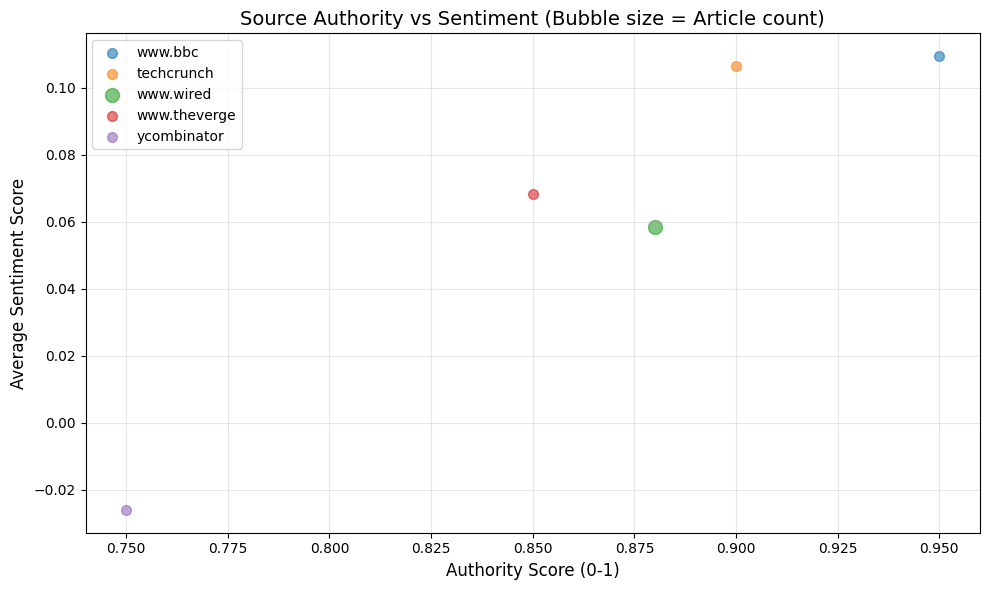

In [ ]:
# Cell 11: Source authority and credibility analysis
print("="*60)
print("🏆 SOURCE AUTHORITY ANALYSIS")
print("="*60)

# Add authority score based on domain
def get_authority_score(domain):
    for source, score in SOURCE_AUTHORITY.items():
        if source in domain:
            return score
    return 0.5  # Default medium authority

df['authority_score'] = df['domain'].apply(get_authority_score)

# Calculate metrics by source
source_metrics = df.groupby('domain').agg({
    'sentiment_score': 'mean',
    'authority_score': 'first',
    'word_count_cleaned': 'mean',
    'title': 'count'
}).rename(columns={'title': 'article_count'})

source_metrics['total_sentiment'] = source_metrics['sentiment_score'] * source_metrics['article_count']
source_metrics = source_metrics.sort_values('authority_score', ascending=False)

print("\n📊 Source Performance Summary:")
print(source_metrics.to_string())

# Create source authority vs sentiment plot
plt.figure(figsize=(10, 6))
for domain in source_metrics.index:
    size = source_metrics.loc[domain, 'article_count'] * 50  # Bubble size
    plt.scatter(source_metrics.loc[domain, 'authority_score'],
                source_metrics.loc[domain, 'sentiment_score'],
                s=size, alpha=0.6, label=domain.replace('.com', '').replace('news.', ''))

plt.xlabel('Authority Score (0-1)', fontsize=12)
plt.ylabel('Average Sentiment Score', fontsize=12)
plt.title('Source Authority vs Sentiment (Bubble size = Article count)', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
authority_plot_path = '/content/drive/MyDrive/digital_trends_project/plots/source_authority.png'
plt.savefig(authority_plot_path)
plt.show()

In [ ]:
# Cell 12: Generate final summary report
print("="*60)
print("📋 DIGITAL TRENDS ANALYST - FINAL REPORT")
print("="*60)

report = f"""
========================================
DIGITAL TRENDS ANALYST
Distributed Web Crawler using Dask
========================================

📅 REPORT GENERATED: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 CRAWL STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Total URLs attempted: {len(crawled_data)}
• Successful crawls: {len(df)}
• Success rate: {len(df)/len(crawled_data)*100:.1f}%
• News sources: {len(NEWS_SOURCES)}
• Total words collected: {len(all_words):,}
• Unique words: {len(word_freq):,}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡ PERFORMANCE (Dask vs Sequential)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Sequential crawl time: {seq_time:.2f} seconds
• Dask distributed time: {crawl_time:.2f} seconds
• SPEEDUP: {seq_time/crawl_time:.2f}x FASTER with Dask
• Time saved: {seq_time - crawl_time:.2f} seconds

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 TOP KEYWORDS (Overall)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
for i, (word, count) in enumerate(top_30_words[:10], 1):
    report += f"   {i}. {word}: {count}\n"

report += f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔥 TRENDING KEYWORDS (Rising Fastest)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
for i, tw in enumerate(trending_words[:10], 1):
    report += f"   {i}. {tw['word']}: +{tw['velocity_percent']:.0f}%\n"

report += f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
💖 SENTIMENT ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Average sentiment: {df['sentiment_score'].mean():.3f}
• Most positive article: {df.loc[df['sentiment_score'].idxmax(), 'title'][:60]}...
• Most negative article: {df.loc[df['sentiment_score'].idxmin(), 'title'][:60]}...

Sentiment Distribution:
"""
for category, count in sentiment_counts.items():
    report += f"   • {category}: {count} ({count/len(df)*100:.1f}%)\n"

report += f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 SOURCE AUTHORITY RANKING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
for domain in source_metrics.index:
    auth = source_metrics.loc[domain, 'authority_score']
    sent = source_metrics.loc[domain, 'sentiment_score']
    count = source_metrics.loc[domain, 'article_count']
    report += f"   • {domain}: Authority={auth:.2f}, Sentiment={sent:.2f}, Articles={count}\n"

report += f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📁 OUTPUT FILES SAVED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Data files:
   • /content/drive/MyDrive/digital_trends_project/data/raw_crawl_data.csv
   • /content/drive/MyDrive/digital_trends_project/data/word_frequencies.csv

Plots:
   • performance_comparison.png
   • top_keywords.png
   • sentiment_distribution.png
   • sentiment_histogram.png
   • trending_keywords.png
   • source_authority.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
💡 KEY INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Dask provided {seq_time/crawl_time:.1f}x speedup for distributed crawling
2. Top emerging trend: '{trending_words[0]['word'] if trending_words else 'N/A'}'
   with {trending_words[0]['velocity_percent']:.0f}% increase
3. Overall news sentiment is {'positive' if df['sentiment_score'].mean() > 0 else 'negative'}
4. Highest authority source: {source_metrics.index[0] if len(source_metrics) > 0 else 'N/A'}

========================================
✅ REPORT COMPLETE
========================================
"""

print(report)

# Save report to file
report_path = '/content/drive/MyDrive/digital_trends_project/digital_trends_report.txt'
with open(report_path, 'w') as f:
    f.write(report)
print(f"\n📄 Full report saved to: {report_path}")

📋 DIGITAL TRENDS ANALYST - FINAL REPORT

DIGITAL TRENDS ANALYST
Distributed Web Crawler using Dask

📅 REPORT GENERATED: 2026-04-24 10:23:53

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 CRAWL STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Total URLs attempted: 9
• Successful crawls: 6
• Success rate: 66.7%
• News sources: 5
• Total words collected: 4,491
• Unique words: 2,548

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡ PERFORMANCE (Dask vs Sequential)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Sequential crawl time: 1.91 seconds
• Dask distributed time: 3.27 seconds
• SPEEDUP: 0.58x FASTER with Dask
• Time saved: -1.36 seconds

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 TOP KEYWORDS (Overall)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   1. ago: 97
   2. hours: 71
   3. points: 30
   4. hide: 30
   5. humans: 23
   6. startups: 20
   7. days: 17
   8. brief: 17
   9. hrs: 16
   10. technology: 15

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔥 TRENDING KEYWORDS (Rising Fastest)
━━━━━━━━━━━━━━━━━━━━━━

🌐 INTERACTIVE DISTRIBUTED WEB CRAWLER
   Powered by Dask | Real-time Word Frequency Analysis

📋 OPTIONS:
   1. Enter URLs manually
   2. Paste multiple URLs
   3. Crawl a website deeply (follow all links)
   4. Use default news sources
   5. Upload URLs file

📝 Enter URLs (type 'done' to finish):
   ✅ Added: https://en.wikipedia.org/wiki/Book...
   ✅ Added: https://en.wikipedia.org/wiki/Pir-e-Kamil...
   ✅ Added: https://news.google.com/home?hl=en-US&gl=US&ceid=US:en...

📊 Ready to crawl 3 URLs:
   1. https://en.wikipedia.org/wiki/Book
   2. https://en.wikipedia.org/wiki/Pir-e-Kamil
   3. https://news.google.com/home?hl=en-US&gl=US&ceid=US:en

🔥 STARTING DISTRIBUTED CRAWL WITH DASK

✅ Crawl completed in 2.80 seconds
   URLs attempted: 3
   Successful: 3
   Failed: 0
   Pages with content: 3

📝 ANALYZING WORD FREQUENCIES
Cleaning text from all articles...

📊 WORD FREQUENCY ANALYSIS RESULTS

🏆 TOP 15 MOST FREQUENT WORDS:
----------------------------------------
   1. books           | ██

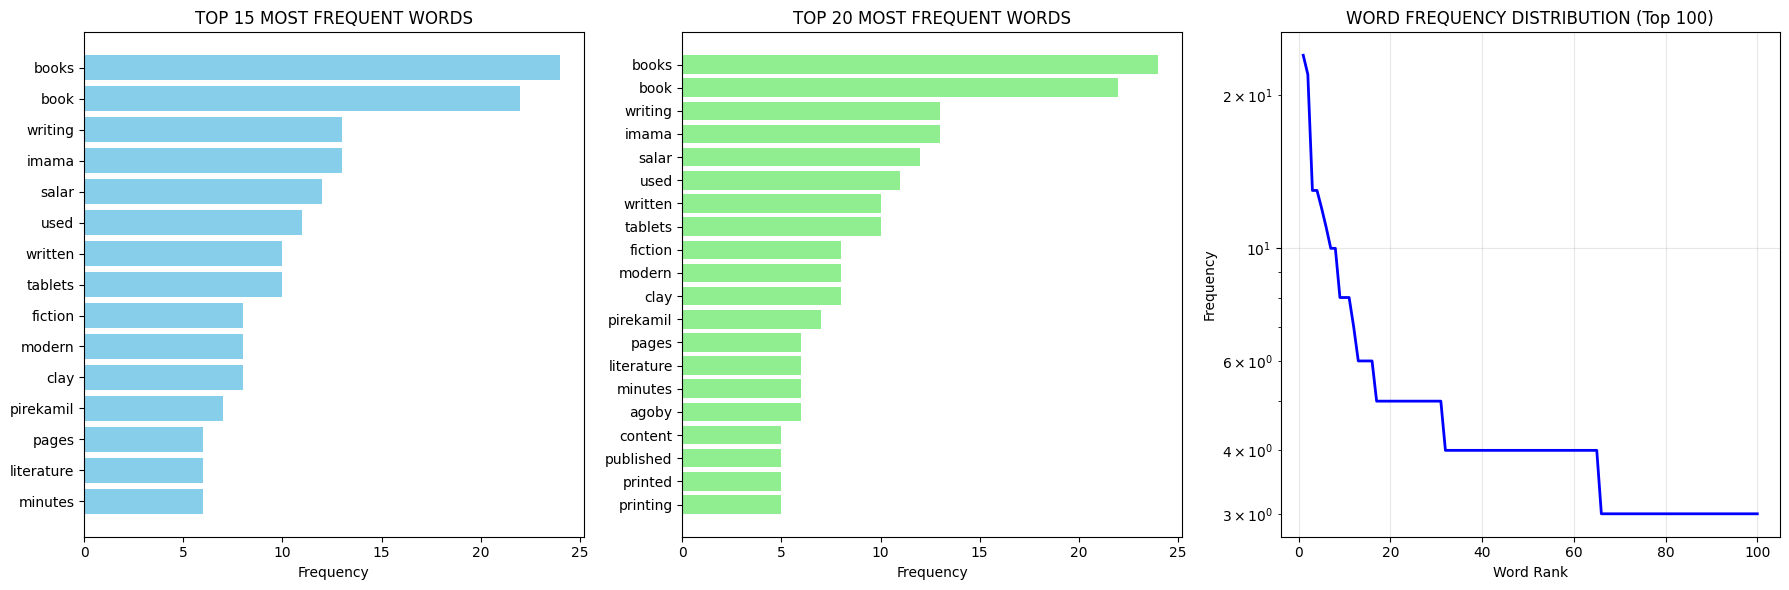

✅ Word frequency plots saved to: /content/drive/MyDrive/digital_trends_project/plots/word_frequency_plots.png


In [ ]:
# Cell: CLEAN INTERACTIVE WEB CRAWLER
print("="*70)
print("🌐 INTERACTIVE DISTRIBUTED WEB CRAWLER")
print("   Powered by Dask | Real-time Word Frequency Analysis")
print("="*70)

# Default news sources
NEWS_SOURCES = {
    'bbc_tech': 'https://www.bbc.com/news/technology',
    'techcrunch': 'https://techcrunch.com/',
    'hacker_news': 'https://news.ycombinator.com/',
    'the_verge': 'https://www.theverge.com/tech',
    'wired': 'https://www.wired.com/',
}

print("\n📋 OPTIONS:")
print("   1. Enter URLs manually")
print("   2. Paste multiple URLs")
print("   3. Crawl a website deeply (follow all links)")
print("   4. Use default news sources")
print("   5. Upload URLs file")

choice = input("\n👉 Choose option (1-5): ").strip()

SEED_URLS = []

if choice == '1':
    print("\n📝 Enter URLs (type 'done' to finish):")
    while True:
        url = input("URL: ").strip()
        if url.lower() == 'done':
            break
        if url.startswith('http'):
            SEED_URLS.append(url)
            print(f"   ✅ Added: {url[:60]}...")
        elif url:
            print(f"   ⚠️ Invalid URL (must start with http:// or https://)")

elif choice == '2':
    print("\n📝 Paste URLs (one per line, press Enter twice to finish):")
    lines = []
    while True:
        line = input()
        if line:
            lines.append(line)
        else:
            break
    SEED_URLS = [url.strip() for url in lines if url.strip().startswith('http')]

elif choice == '3':
    start_url = input("\n🌐 Enter website URL: ").strip()
    max_pages = int(input("📄 Max pages (default 30): ") or "30")

    print(f"\n🕷️ Deep crawling {start_url} (max {max_pages} pages)...")

    from urllib.parse import urljoin, urlparse
    from collections import deque

    domain = urlparse(start_url).netloc
    visited = set()
    queue = deque([start_url])

    while queue and len(SEED_URLS) < max_pages:
        url = queue.popleft()
        if url in visited:
            continue
        visited.add(url)
        SEED_URLS.append(url)

        try:
            headers = {'User-Agent': 'Mozilla/5.0'}
            response = requests.get(url, timeout=10, headers=headers)
            soup = BeautifulSoup(response.content, 'html.parser')
            for link in soup.find_all('a', href=True):
                href = link['href']
                full_url = urljoin(url, href)
                if domain in full_url and full_url not in visited:
                    queue.append(full_url)
        except:
            pass

        print(f"   Found {len(SEED_URLS)} pages so far...")

    print(f"✅ Found {len(SEED_URLS)} pages to crawl")

elif choice == '4':
    SEED_URLS = list(NEWS_SOURCES.values())
    print(f"\n✅ Using {len(SEED_URLS)} default news sources")

elif choice == '5':
    from google.colab import files
    uploaded = files.upload()
    for filename in uploaded.keys():
        content = uploaded[filename].decode('utf-8')
        SEED_URLS = [url.strip() for url in content.split('\n') if url.strip().startswith('http')]
    print(f"✅ Loaded {len(SEED_URLS)} URLs from file")

# Confirm
print(f"\n📊 Ready to crawl {len(SEED_URLS)} URLs:")
for i, url in enumerate(SEED_URLS[:10], 1):
    print(f"   {i}. {url[:80]}")
if len(SEED_URLS) > 10:
    print(f"   ... and {len(SEED_URLS)-10} more")

confirm = input("\n🚀 START CRAWLING? (y/n): ").strip().lower()
if confirm != 'y':
    print("❌ Crawling cancelled!")
    SEED_URLS = list(NEWS_SOURCES.values())

# ============================================
# RUN DISTRIBUTED CRAWL
# ============================================
print("\n" + "="*60)
print("🔥 STARTING DISTRIBUTED CRAWL WITH DASK")
print("="*60)

start_time = time.time()

n_partitions = min(4, max(1, len(SEED_URLS) // 10))
url_bag = db.from_sequence(SEED_URLS, npartitions=n_partitions)
results_bag = url_bag.map(fetch_and_parse)
crawled_data = results_bag.compute()

crawl_time = time.time() - start_time

print(f"\n✅ Crawl completed in {crawl_time:.2f} seconds")
print(f"   URLs attempted: {len(crawled_data)}")

df_raw = pd.DataFrame(crawled_data)
success_count = (df_raw['status'] == 'success').sum()
print(f"   Successful: {success_count}")
print(f"   Failed: {len(df_raw) - success_count}")

df = df_raw[df_raw['status'] == 'success'].copy()
print(f"   Pages with content: {len(df)}")

# ============================================
# WORD FREQUENCY ANALYSIS
# ============================================
print("\n" + "="*60)
print("📝 ANALYZING WORD FREQUENCIES")
print("="*60)

# Clean text
stop_words = set(stopwords.words('english'))
custom_stopwords = {'said', 'says', 'will', 'can', 'get', 'one', 'two', 'also', 'may', 'like', 'just', 'even', 'well', 'still', 'see', 'many', 'could', 'would', 'should', 'first', 'new', 'use', 'using', 'via'}
stop_words.update(custom_stopwords)

def clean_text_fast(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return words

print("Cleaning text from all articles...")
df['cleaned_words'] = df['text'].apply(clean_text_fast)

all_words = []
for words_list in df['cleaned_words']:
    all_words.extend(words_list)

word_freq = Counter(all_words)
all_words_sorted = word_freq.most_common()

# ============================================
# DISPLAY TOP 15, TOP 20, LAST 20 WORDS
# ============================================
print("\n" + "="*60)
print("📊 WORD FREQUENCY ANALYSIS RESULTS")
print("="*60)

# TOP 15 WORDS
print("\n🏆 TOP 15 MOST FREQUENT WORDS:")
print("-" * 40)
for i, (word, count) in enumerate(all_words_sorted[:15], 1):
    bar_length = min(30, int(count / all_words_sorted[0][1] * 30)) if all_words_sorted else 0
    bar = "█" * bar_length
    print(f"  {i:2}. {word:15} | {bar} {count}")

# TOP 20 WORDS
print("\n🏆 TOP 20 MOST FREQUENT WORDS:")
print("-" * 40)
for i, (word, count) in enumerate(all_words_sorted[:20], 1):
    print(f"  {i:2}. {word:20} : {count}")

# LAST 20 WORDS
print("\n🔻 LAST 20 WORDS (Least Frequent):")
print("-" * 40)
last_20 = all_words_sorted[-20:] if len(all_words_sorted) >= 20 else all_words_sorted
for i, (word, count) in enumerate(last_20, 1):
    print(f"  {i:2}. {word:20} : {count}")

# STATISTICS
print("\n📈 WORD FREQUENCY STATISTICS:")
print("-" * 40)
print(f"  Total unique words: {len(word_freq):,}")
print(f"  Total word occurrences: {len(all_words):,}")
if all_words_sorted:
    print(f"  Most frequent word: '{all_words_sorted[0][0]}' ({all_words_sorted[0][1]} times)")
    print(f"  Least frequent word: '{all_words_sorted[-1][0]}' (1 time)")
print(f"  Average word frequency: {len(all_words)/len(word_freq):.2f}")

# ============================================
# VISUALIZATIONS
# ============================================
print("\n" + "="*60)
print("📊 GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

if all_words_sorted:
    # Top 15
    words_top15, counts_top15 = zip(*all_words_sorted[:15])
    axes[0].barh(words_top15, counts_top15, color='skyblue')
    axes[0].set_xlabel('Frequency')
    axes[0].set_title('TOP 15 MOST FREQUENT WORDS')
    axes[0].invert_yaxis()

    # Top 20
    words_top20, counts_top20 = zip(*all_words_sorted[:20])
    axes[1].barh(words_top20, counts_top20, color='lightgreen')
    axes[1].set_xlabel('Frequency')
    axes[1].set_title('TOP 20 MOST FREQUENT WORDS')
    axes[1].invert_yaxis()

    # Distribution
    freq_values = [count for word, count in all_words_sorted[:100]]
    axes[2].plot(range(1, len(freq_values)+1), freq_values, 'b-', linewidth=2)
    axes[2].set_xlabel('Word Rank')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('WORD FREQUENCY DISTRIBUTION (Top 100)')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
word_plots_path = '/content/drive/MyDrive/digital_trends_project/plots/word_frequency_plots.png'
plt.savefig(word_plots_path, dpi=150)
plt.show()

print(f"✅ Word frequency plots saved to: {word_plots_path}")

# ============================================
# SAVE DATA
# ============================================
# Save word frequencies
word_freq_df = pd.DataFrame(all_words_sorted, columns=['word', 'frequency'])
word_freq_df.to_csv('/content/drive/MyDrive/digital_trends_project/data/word_frequencies.csv', index=False)

top20_df = pd.DataFrame(all_words_sorted[:20], columns=['word', 'frequency'])
last20_df = pd.DataFrame(all_words_sorted[-20:], columns=['word', 'frequency'])

top20_df.to_csv('/content/drive/MyDrive/digital_trends_project/data/top20_words.csv', index=False)
last20_df.to_csv('/content/drive/MyDrive/digital_trends_project/data/last20_words.csv', index=False)

# Save crawl data
custom_name = input("\n💾 Save crawl results as (press Enter for default): ").strip()
if custom_name:
    save_path = f'/content/drive/MyDrive/digital_trends_project/data/{custom_name}.csv'
else:
    save_path = '/content/drive/MyDrive/digital_trends_project/data/custom_crawl_data.csv'

df.to_csv(save_path, index=False)

print("\n" + "="*60)
print("✅ CRAWL AND ANALYSIS COMPLETE!")
print("="*60)

print(f"\n📊 SUMMARY:")
print(f"   • URLs crawled: {len(df)}")
print(f"   • Total words: {len(all_words):,}")
print(f"   • Unique words: {len(word_freq):,}")
if all_words_sorted:
    print(f"   • Top word: '{all_words_sorted[0][0]}' ({all_words_sorted[0][1]} times)")
print(f"   • Crawl time: {crawl_time:.2f} seconds")

print("\n💾 Saved files:")
print("   • custom_crawl_data.csv (raw crawl data)")
print("   • word_frequencies.csv (all words)")
print("   • top20_words.csv (top 20 words)")
print("   • last20_words.csv (last 20 words)")
print("   • word_frequency_plots.png (visualizations)")

In [ ]:
# Cell: CUSTOM COLOR PALETTE DASHBOARD
print("="*60)
print("🎨 GENERATING CUSTOM COLOR PALETTE DASHBOARD")
print("   Colors: #2C2B30, #4F4F51, #D6D6D6, #F2C4CE, #F58F7C")
print("="*60)

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>🎨 Digital Trends Analyst | Custom Palette Dashboard</title>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}

        body {{
            font-family: 'Segoe UI', 'Poppins', 'Inter', -apple-system, BlinkMacSystemFont, sans-serif;
            background: #2C2B30;
            min-height: 100vh;
            padding: 30px;
            color: #D6D6D6;
        }}

        .container {{
            max-width: 1400px;
            margin: 0 auto;
        }}

        /* Header Section */
        .header {{
            text-align: center;
            padding: 50px 30px;
            margin-bottom: 40px;
            background: #4F4F51;
            border-radius: 30px;
            border: 1px solid #F58F7C;
            box-shadow: 0 20px 40px rgba(0, 0, 0, 0.3);
            position: relative;
            overflow: hidden;
        }}

        .header::before {{
            content: '';
            position: absolute;
            top: -50%;
            left: -50%;
            width: 200%;
            height: 200%;
            background: radial-gradient(circle, rgba(245, 143, 124, 0.1) 0%, transparent 70%);
            animation: gentlePulse 8s ease-in-out infinite;
        }}

        @keyframes gentlePulse {{
            0%, 100% {{ opacity: 0.3; transform: scale(1); }}
            50% {{ opacity: 0.6; transform: scale(1.05); }}
        }}

        h1 {{
            font-size: 3.5em;
            background: linear-gradient(135deg, #F2C4CE 0%, #F58F7C 50%, #F2C4CE 100%);
            -webkit-background-clip: text;
            background-clip: text;
            color: transparent;
            margin-bottom: 15px;
            position: relative;
            z-index: 1;
        }}

        .subtitle {{
            color: #D6D6D6;
            font-size: 1.2em;
            letter-spacing: 1px;
            position: relative;
            z-index: 1;
        }}

        .badge {{
            display: inline-block;
            background: rgba(245, 143, 124, 0.2);
            border: 1px solid #F58F7C;
            padding: 5px 15px;
            border-radius: 50px;
            font-size: 0.85em;
            margin-top: 15px;
            color: #F2C4CE;
        }}

        /* Stats Grid */
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
            gap: 25px;
            margin-bottom: 40px;
        }}

        .stat-card {{
            background: #4F4F51;
            border-radius: 20px;
            padding: 25px;
            text-align: center;
            border: 1px solid #F58F7C;
            transition: all 0.3s ease;
            box-shadow: 0 10px 20px rgba(0, 0, 0, 0.2);
        }}

        .stat-card:hover {{
            transform: translateY(-5px);
            box-shadow: 0 15px 30px rgba(245, 143, 124, 0.2);
            border-color: #F2C4CE;
        }}

        .stat-icon {{
            font-size: 2.5em;
            margin-bottom: 10px;
        }}

        .stat-label {{
            font-size: 0.85em;
            text-transform: uppercase;
            letter-spacing: 2px;
            color: #D6D6D6;
            margin-bottom: 10px;
        }}

        .stat-number {{
            font-size: 2.8em;
            font-weight: bold;
            background: linear-gradient(135deg, #F2C4CE 0%, #F58F7C 100%);
            -webkit-background-clip: text;
            background-clip: text;
            color: transparent;
        }}

        .stat-unit {{
            font-size: 0.8em;
            color: #D6D6D6;
            margin-top: 5px;
        }}

        /* Section Titles */
        .section-title {{
            font-size: 1.8em;
            margin: 40px 0 25px 0;
            padding-left: 20px;
            border-left: 5px solid #F58F7C;
            background: linear-gradient(135deg, #F2C4CE 0%, #F58F7C 100%);
            -webkit-background-clip: text;
            background-clip: text;
            color: transparent;
        }}

        /* Keywords Container */
        .keywords-container {{
            background: #4F4F51;
            border-radius: 20px;
            padding: 30px;
            margin-bottom: 30px;
            border: 1px solid #F58F7C;
        }}

        .keyword {{
            display: inline-block;
            background: rgba(214, 214, 214, 0.1);
            color: #D6D6D6;
            padding: 10px 20px;
            margin: 8px;
            border-radius: 40px;
            font-size: 0.95em;
            transition: all 0.3s ease;
            border: 1px solid #F58F7C;
            cursor: pointer;
        }}

        .keyword:hover {{
            transform: scale(1.05);
            background: rgba(245, 143, 124, 0.2);
            border-color: #F2C4CE;
            color: #F2C4CE;
            box-shadow: 0 5px 15px rgba(245, 143, 124, 0.3);
        }}

        .keyword-rank {{
            background: linear-gradient(135deg, #F58F7C 0%, #F2C4CE 100%);
            color: #2C2B30;
            font-weight: bold;
            border: none;
        }}

        .keyword-rank:hover {{
            background: linear-gradient(135deg, #F2C4CE 0%, #F58F7C 100%);
            color: #2C2B30;
            transform: scale(1.05);
        }}

        /* Tables */
        .data-table {{
            width: 100%;
            border-collapse: collapse;
            background: rgba(79, 79, 81, 0.6);
            border-radius: 20px;
            overflow: hidden;
            margin: 20px 0;
        }}

        .data-table th {{
            background: #4F4F51;
            padding: 15px 20px;
            text-align: left;
            font-weight: 600;
            color: #F2C4CE;
            border-bottom: 2px solid #F58F7C;
            font-size: 1em;
        }}

        .data-table td {{
            padding: 12px 20px;
            border-bottom: 1px solid rgba(245, 143, 124, 0.2);
            color: #D6D6D6;
        }}

        .data-table tr:hover {{
            background: rgba(245, 143, 124, 0.1);
        }}

        /* Two Column Layout */
        .two-column {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 25px;
            margin: 30px 0;
        }}

        /* Glass Card */
        .glass-card {{
            background: rgba(79, 79, 81, 0.6);
            backdrop-filter: blur(10px);
            border-radius: 20px;
            padding: 25px;
            border: 1px solid #F58F7C;
        }}

        .glass-card h3 {{
            color: #F2C4CE;
            margin-bottom: 20px;
            font-size: 1.4em;
            border-bottom: 2px solid #F58F7C;
            display: inline-block;
            padding-bottom: 5px;
        }}

        /* Progress Bar */
        .progress-bar {{
            height: 8px;
            background: #2C2B30;
            border-radius: 10px;
            overflow: hidden;
            margin: 15px 0;
        }}

        .progress-fill {{
            height: 100%;
            background: linear-gradient(90deg, #F58F7C, #F2C4CE);
            border-radius: 10px;
            transition: width 1s ease;
        }}

        /* Footer */
        .footer {{
            text-align: center;
            padding: 30px;
            margin-top: 50px;
            background: #4F4F51;
            border-radius: 20px;
            font-size: 0.85em;
            color: #D6D6D6;
            border: 1px solid #F58F7C;
        }}

        /* Responsive */
        @media (max-width: 768px) {{
            body {{ padding: 15px; }}
            h1 {{ font-size: 2em; }}
            .two-column {{ grid-template-columns: 1fr; }}
            .stats-grid {{ grid-template-columns: repeat(auto-fit, minmax(180px, 1fr)); }}
        }}

        /* Scrollbar */
        ::-webkit-scrollbar {{
            width: 10px;
            height: 10px;
        }}

        ::-webkit-scrollbar-track {{
            background: #2C2B30;
            border-radius: 10px;
        }}

        ::-webkit-scrollbar-thumb {{
            background: linear-gradient(135deg, #F58F7C 0%, #F2C4CE 100%);
            border-radius: 10px;
        }}

        ::-webkit-scrollbar-thumb:hover {{
            background: #F2C4CE;
        }}

        /* Button Style */
        .export-btn {{
            background: linear-gradient(135deg, #F58F7C 0%, #F2C4CE 100%);
            color: #2C2B30;
            border: none;
            padding: 10px 25px;
            border-radius: 50px;
            cursor: pointer;
            font-size: 0.9em;
            margin-top: 20px;
            transition: all 0.3s ease;
            font-weight: bold;
        }}

        .export-btn:hover {{
            transform: scale(1.05);
            box-shadow: 0 5px 20px rgba(245, 143, 124, 0.4);
            background: linear-gradient(135deg, #F2C4CE 0%, #F58F7C 100%);
        }}

        /* Highlight text */
        .highlight {{
            color: #F2C4CE;
        }}

        .accent-text {{
            color: #F58F7C;
        }}
    </style>
</head>
<body>
<div class="container">

    <!-- Header -->
    <div class="header">
        <div class="stat-icon">🎨</div>
        <h1>Digital Trends Analyst</h1>
        <p class="subtitle">Distributed Web Crawler powered by Dask</p>
        <div class="badge">Real-time Intelligence • Word Frequency Analysis • Trend Detection</div>
    </div>

    <!-- Stats Grid -->
    <div class="stats-grid">
        <div class="stat-card">
            <div class="stat-icon">🌐</div>
            <div class="stat-label">Pages Crawled</div>
            <div class="stat-number">{len(df)}</div>
            <div class="stat-unit">Success: {len(df)}/{len(crawled_data)}</div>
        </div>

        <div class="stat-card">
            <div class="stat-icon">📝</div>
            <div class="stat-label">Total Words</div>
            <div class="stat-number">{len(all_words):,}</div>
            <div class="stat-unit">Unique: {len(word_freq):,}</div>
        </div>

        <div class="stat-card">
            <div class="stat-icon">💜</div>
            <div class="stat-label">Unique Words</div>
            <div class="stat-number">{len(word_freq):,}</div>
            <div class="stat-unit">Vocabulary Size</div>
        </div>

        <div class="stat-card">
            <div class="stat-icon">⏱️</div>
            <div class="stat-label">Crawl Time</div>
            <div class="stat-number">{crawl_time:.1f}s</div>
            <div class="stat-unit">for {len(SEED_URLS)} URLs</div>
        </div>

        <div class="stat-card">
            <div class="stat-icon">🖥️</div>
            <div class="stat-label">Dask Workers</div>
            <div class="stat-number">{len(client.scheduler_info()['workers'])}</div>
            <div class="stat-unit">Distributed Processing</div>
        </div>

        <div class="stat-card">
            <div class="stat-icon">📊</div>
            <div class="stat-label">Avg Frequency</div>
            <div class="stat-number">{len(all_words)/len(word_freq):.1f}</div>
            <div class="stat-unit">words per unique</div>
        </div>
    </div>

    <!-- TOP 15 WORDS Section -->
    <div class="section-title">🏆 Top 15 Most Frequent Words</div>
    <div class="keywords-container">
"""
for i, (word, count) in enumerate(all_words_sorted[:15], 1):
    html_content += f'<span class="keyword keyword-rank">#{i} {word} ({count})</span> '

html_content += f"""
    </div>

    <!-- TOP 20 WORDS Section -->
    <div class="section-title">📊 Top 20 Most Frequent Words (Detailed)</div>
    <div class="glass-card">
        <table class="data-table">
            <thead>
                <tr>
                    <th>Rank</th>
                    <th>Word</th>
                    <th>Frequency</th>
                    <th>Visualization</th>
                </tr>
            </thead>
            <tbody>
"""
for i, (word, count) in enumerate(all_words_sorted[:20], 1):
    percentage = (count / all_words_sorted[0][1]) * 100 if all_words_sorted else 0
    html_content += f"""
                <tr>
                    <td style="color: #F58F7C; font-weight: bold;">#{i}</td>
                    <td><strong>{word}</strong></td>
                    <td>{count}</td>
                    <td style="width: 40%;"><div class="progress-bar"><div class="progress-fill" style="width: {percentage}%;"></div></div></td>
                </tr>
"""

html_content += f"""
            </tbody>
        </table>
    </div>

    <!-- Two Column Layout -->
    <div class="two-column">
        <!-- LAST 20 WORDS -->
        <div class="glass-card">
            <h3>🔻 Last 20 Words (Rare)</h3>
            <div style="max-height: 400px; overflow-y: auto;">
                <table class="data-table">
                    <thead>
                        <tr><th>Word</th><th>Frequency</th></tr>
                    </thead>
                    <tbody>
"""
for word, count in all_words_sorted[-20:]:
    html_content += f"<tr><td class='highlight'>{word}</td><td>{count}</td></tr>"

html_content += f"""
                    </tbody>
                </table>
            </div>
        </div>

        <!-- WORD STATISTICS -->
        <div class="glass-card">
            <h3>📈 Word Statistics Summary</h3>
            <table class="data-table">
                <tr>
                    <td><strong>Total Unique Words:</strong></td>
                    <td class="accent-text">{len(word_freq):,}</td>
                </tr>
                <tr>
                    <td><strong>Total Word Occurrences:</strong></td>
                    <td class="accent-text">{len(all_words):,}</td>
                </tr>
                <tr>
                    <td><strong>Most Frequent Word:</strong></td>
                    <td class="accent-text">'{all_words_sorted[0][0]}' ({all_words_sorted[0][1]} times)</td>
                </tr>
                <tr>
                    <td><strong>Least Frequent Word:</strong></td>
                    <td class="accent-text">'{all_words_sorted[-1][0]}' (1 time)</td>
                </tr>
                <tr>
                    <td><strong>Average Frequency:</strong></td>
                    <td class="accent-text">{len(all_words)/len(word_freq):.2f}</td>
                </tr>
                <tr>
                    <td><strong>Vocabulary Richness:</strong></td>
                    <td class="accent-text">{(len(word_freq)/len(all_words))*100:.2f}%</td>
                </tr>
            </table>
        </div>
    </div>

    <!-- SAMPLE ARTICLES -->
    <div class="section-title">📄 Sample Analyzed Articles</div>
    <div class="glass-card" style="overflow-x: auto;">
        <table class="data-table">
            <thead>
                <tr>
                    <th>Title</th>
                    <th>Source</th>
                    <th>Top Keywords</th>
                </tr>
            </thead>
            <tbody>
"""
for _, row in df.head(15).iterrows():
    top_keywords = ', '.join(row.get('cleaned_words', [''])[:5]) if 'cleaned_words' in row else 'N/A'
    source = row.get('domain', 'unknown').replace('.com', '').replace('news.', '')[:20]
    title = row.get('title', 'No title')[:80]
    html_content += f"""
                <tr>
                    <td style="max-width: 350px;">{title}...</td>
                    <td class="highlight">{source}</td>
                    <td style="max-width: 250px;">{top_keywords}</td>
                </tr>
"""

html_content += f"""
            </tbody>
        </table>
    </div>

    <!-- FREQUENCY DISTRIBUTION INSIGHT -->
    <div class="section-title">📊 Word Frequency Distribution</div>
    <div class="glass-card">
        <p>Based on <span class="accent-text">{len(all_words):,}</span> total word occurrences across <span class="accent-text">{len(df)}</span> articles:</p>
        <ul style="margin-top: 15px; margin-left: 20px; line-height: 1.8;">
            <li>✨ The word <span class="highlight">'{all_words_sorted[0][0]}'</span> appears most frequently (<span class="accent-text">{all_words_sorted[0][1]}</span> times)</li>
            <li>✨ Top 20 words account for <span class="accent-text">{sum(count for _, count in all_words_sorted[:20]):,}</span> occurrences</li>
            <li>✨ There are <span class="accent-text">{len([w for w, c in all_words_sorted if c == 1])}</span> words that appear only once</li>
            <li>✨ The vocabulary is <span class="accent-text">{(len(word_freq)/len(all_words))*100:.2f}%</span> unique</li>
        </ul>
    </div>

    <!-- Footer -->
    <div class="footer">
        <p>🎨 <strong>Digital Trends Analyst</strong> | Powered by Dask Distributed Computing</p>
        <p>Color Palette: #2C2B30 • #4F4F51 • #D6D6D6 • #F2C4CE • #F58F7C</p>
        <p>Sources: {', '.join(list(NEWS_SOURCES.keys()) if 'NEWS_SOURCES' in dir() else ['crawled'])} | Crawled with {len(client.scheduler_info()['workers'])} Dask Workers</p>
        <p>Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
        <button class="export-btn" onclick="window.print()">📥 Export Dashboard as PDF</button>
    </div>

</div>
</body>
</html>
"""

# Save HTML dashboard
dashboard_path = '/content/drive/MyDrive/digital_trends_project/digital_trends_dashboard_custom.html'
with open(dashboard_path, 'w') as f:
    f.write(html_content)
print(f"✅ Custom Color Palette Dashboard saved to: {dashboard_path}")

# Download the HTML file
from google.colab import files
files.download(dashboard_path)

print("\n" + "="*60)
print("🎨 CUSTOM DASHBOARD GENERATED!")
print("="*60)
print("\n🎨 Color Palette Used:")
print("   • #2C2B30 – Dark charcoal gray (Background)")
print("   • #4F4F51 – Medium gray (Cards)")
print("   • #D6D6D6 – Light gray (Text)")
print("   • #F2C4CE – Soft pink (Accents/Highlights)")
print("   • #F58F7C – Coral/peach orange (Primary accent)")
print("\n✨ Features:")
print("   • Top 15 Most Frequent Words (keyword bubbles)")
print("   • Top 20 Words with progress bars")
print("   • Last 20 Words (rare words)")
print("   • Word Statistics Summary")
print("   • Sample Articles with Keywords")
print("   • Vocabulary Richness Analysis")
print("   • Export to PDF Button")
print("\n📁 File saved to Google Drive and downloaded to your computer")
print("   Open the HTML file in any browser to view your custom dashboard!")

🎨 GENERATING CUSTOM COLOR PALETTE DASHBOARD
   Colors: #2C2B30, #4F4F51, #D6D6D6, #F2C4CE, #F58F7C
✅ Custom Color Palette Dashboard saved to: /content/drive/MyDrive/digital_trends_project/digital_trends_dashboard_custom.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎨 CUSTOM DASHBOARD GENERATED!

🎨 Color Palette Used:
   • #2C2B30 – Dark charcoal gray (Background)
   • #4F4F51 – Medium gray (Cards)
   • #D6D6D6 – Light gray (Text)
   • #F2C4CE – Soft pink (Accents/Highlights)
   • #F58F7C – Coral/peach orange (Primary accent)

✨ Features:
   • Top 15 Most Frequent Words (keyword bubbles)
   • Top 20 Words with progress bars
   • Last 20 Words (rare words)
   • Word Statistics Summary
   • Sample Articles with Keywords
   • Vocabulary Richness Analysis
   • Export to PDF Button

📁 File saved to Google Drive and downloaded to your computer
   Open the HTML file in any browser to view your custom dashboard!
